In [22]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import ndimage
import glob

RAW_PATH = Path('../data/raw/Original')
CLASSES  = ['Benign', 'Early', 'Pre', 'Pro']
COLORES  = {'Benign': '#2ecc71', 'Early': '#e74c3c', 'Pre': '#e67e22', 'Pro': '#9b59b6'}

print('Librerías cargadas OK')

Librerías cargadas OK


In [23]:
def preprocesamiento(img_path, filtro='mediana', ksize=5):
    """
    Pipeline completo de preprocesamiento:
      1. Carga imagen
      2. Convierte a HSV y extrae canal S
      3. Aplica filtro de ruido mediana
    Retorna: imagen original RGB, canal S sin procesar, canal S preprocesado
    """
    img_bgr = cv2.imread(str(img_path))
    
    # Seguro por si alguna ruta se rompe en otra compu
    if img_bgr is None:
        raise FileNotFoundError(f"No se encontró la imagen en: {img_path}")
    

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    canal_s = img_hsv[:,:,1] # Canal S (Saturación - Índice 1)

    if filtro == 'mediana':
        canal_filtrado = cv2.medianBlur(canal_s, ksize)
    elif filtro == 'gaussiano':
        canal_filtrado = cv2.GaussianBlur(canal_s, (ksize, ksize), 0)
    else:
        canal_filtrado = canal_s
        print(f"Filtro '{filtro}' no reconocido. Se devuelve el canal S limpio.")
    
    return img_rgb, canal_s, canal_filtrado

def refinar_mascara_nucleo(mascara, kernel_size=5):
    """
    Aplica operaciones morfológicas para limpiar la máscara del núcleo:
    1. Apertura: elimina pequeños artefactos y puentes finos.
    2. Cierre: rellena huecos internos en el núcleo.
    3. Relleno de agujeros con SciPy: consolida la máscara final.
    """
    # Usamos un elemento estructurante elíptico (ideal para formas redondeadas de núcleos)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    
    # 1. Apertura (Erosión + Dilatación) - Limpia ruidos externos
    apertura = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
    
    # 2. Cierre (Dilatación + Erosión) - Conecta componentes del mismo núcleo
    cierre = cv2.morphologyEx(apertura, cv2.MORPH_CLOSE, kernel)
    
    # 3. Relleno de agujeros internos (SciPy ndimage)
    relleno = ndimage.binary_fill_holes(cierre).astype(np.uint8) * 255
    
    # Retornamos los pasos intermedios para tu gráfico de visualización, 
    # siendo 'relleno' el resultado final optimizado.
    return apertura, cierre, relleno


def cargar_imagen(ruta):
    """Carga la imagen y devuelve versiones BGR (para OpenCV) y RGB (para matplotlib)."""
    img_bgr = cv2.imread(ruta)
    if img_bgr is None:
        raise ValueError(f"No se pudo cargar la imagen en la ruta: {ruta}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_bgr, img_rgb


def aislar_celula(img_rgb, mask):
    """
    Multiplica la máscara por la imagen original para dejar solo la célula y el fondo negro.
    """
    # cv2.bitwise_and aplica la máscara a la imagen a color
    celula_aislada = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
    return celula_aislada

def segmentar_celula_otsu(canal_proc, umbral_maximo=10):
    """
    Segmenta la célula completa (núcleo + citoplasma) usando Otsu.
    Usa un 'techo' de seguridad: si Otsu se va muy arriba y solo agarra 
    el núcleo, lo forzamos a bajar para incluir el citoplasma.
    """
    # 1. Calculamos Otsu estándar
    umbral_otsu, mascara_otsu = cv2.threshold(
        canal_proc, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    
    # 2. Control de seguridad INVERTIDO: 
    # Si Otsu calculó un umbral muy alto (ej. 100), perdemos el citoplasma. 
    # Lo forzamos a bajar al umbral_maximo.
    if umbral_otsu > umbral_maximo:
        # Re-calculamos usando el umbral fijo más bajo
        _, mascara = cv2.threshold(canal_proc, umbral_maximo, 255, cv2.THRESH_BINARY)
        umbral_final = umbral_maximo
    else:
        mascara = mascara_otsu
        umbral_final = umbral_otsu
        
    return mascara, umbral_final

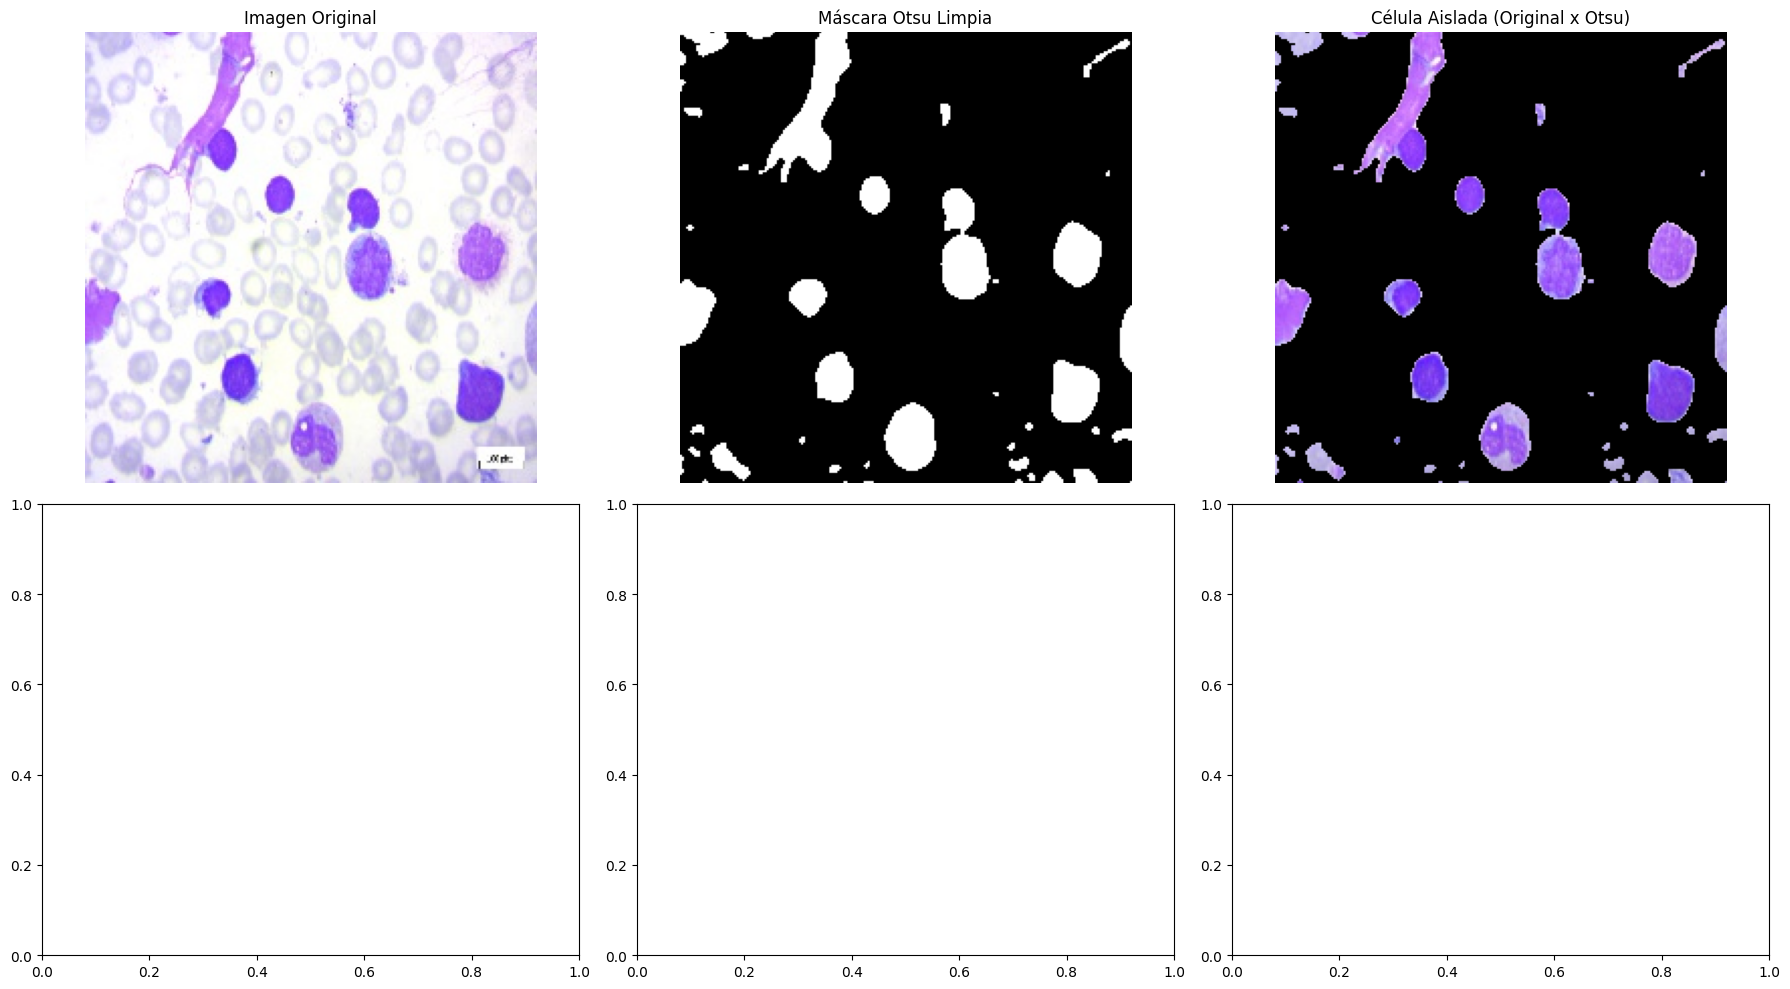

In [24]:
# --- 1. CARGA DE IMAGEN ---
# ¡Asegúrate de cambiar este nombre por el de una de tus imágenes de prueba!
cls = 'Benign'  # Cambia esto por 'Early', 'Pre' o 'Pro' para probar otras clases
ruta_imagen = list((RAW_PATH / cls).glob('*.jpg'))[20]

img_bgr, img_rgb = cargar_imagen(ruta_imagen)

# Paso A: Preprocesamiento (Tu pipeline del Canal S)
img_rgb, canal_s_raw, canal_proc = preprocesamiento(ruta_imagen, filtro='mediana', ksize=5)
    
# Paso B: Segmentación con el NUEVO freno de mano en 70
mask_raw, umbral_calc = segmentar_celula_otsu(canal_proc, umbral_maximo=45)
    
# Paso C: Refinamiento morfológico con el kernel elíptico
apertura, cierre, relleno = refinar_mascara_nucleo(mask_raw, kernel_size=5)
# --- 2. APLICAR MÉTODOS ---
# Otsu

resultado_otsu = aislar_celula(img_rgb, mask_raw)

# --- 3. MOSTRAR RESULTADOS ---
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# Fila 1: Otsu
axs[0, 0].imshow(img_rgb)
axs[0, 0].set_title("Imagen Original")
axs[0, 0].axis('off')

axs[0, 1].imshow(mask_raw, cmap='gray')
axs[0, 1].set_title("Máscara Otsu Limpia")
axs[0, 1].axis('off')

axs[0, 2].imshow(resultado_otsu)
axs[0, 2].set_title("Célula Aislada (Original x Otsu)")
axs[0, 2].axis('off')



plt.tight_layout()
plt.show()

In [74]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def clasificar_y_filtrar_linfocitos(mascara_celula, mascara_nucleo, imagen_original):
    """Filtra objetos basándose en la forma de la célula y, 
    en la circularidad de su núcleo para descartar neutrófilos u otras células no deseadas."""

    contornos_celula, _ = cv2.findContours(mascara_celula, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    mascara_linfocitos = np.zeros_like(mascara_celula)
    caracteristicas_extraidas = []
    
    for cnt in contornos_celula:
        area_celula = cv2.contourArea(cnt)
        
        # 1. Filtro de Área: Bajamos el mínimo a 300 por si la célula del medio era pequeña
        if area_celula < 400 or area_celula > 80000:
            continue
            
        # 2. Solidez de la célula completa (bajamos a 0.75 para ser más permisivos)
        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidez = area_celula / float(hull_area) if hull_area > 0 else 0
        
        # --- 3. ANÁLISIS DEL NÚCLEO ---
        # Aislamos el núcleo que pertenece ÚNICAMENTE a esta célula actual
        mask_esta_celula = np.zeros_like(mascara_celula)
        cv2.drawContours(mask_esta_celula, [cnt], -1, 255, thickness=cv2.FILLED)
        
        nucleo_aislado = cv2.bitwise_and(mascara_nucleo, mascara_nucleo, mask=mask_esta_celula)
        contornos_nuc, _ = cv2.findContours(nucleo_aislado, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if len(contornos_nuc) == 0:
            continue # Si no tiene núcleo, es basura
            
        # Tomamos el núcleo principal de esta célula
        cnt_nucleo = max(contornos_nuc, key=cv2.contourArea)
        area_nuc = cv2.contourArea(cnt_nucleo)
        peri_nuc = cv2.arcLength(cnt_nucleo, True)
        
        # Circularidad del Núcleo
        circularidad_nucleo = 0
        if peri_nuc > 0:
            circularidad_nucleo = 4 * np.pi * (area_nuc / (peri_nuc * peri_nuc))
            
        # --- REGLA DE ORO (Clasificador) ---
        # El núcleo DEBE ser redondo (> 0.55) y la célula medianamente sólida (> 0.75) Se pueden tantear los valores para mejorar
        es_linfocito = (circularidad_nucleo > 0.75) and (solidez > 0.75)
        
        if es_linfocito:
            cv2.drawContours(mascara_linfocitos, [cnt], -1, 255, thickness=cv2.FILLED)
            caracteristicas_extraidas.append({
                'Area_Celula': area_celula,
                'Area_Nucleo': area_nuc,
                'Solidez_Celula': solidez,
                'Circularidad_Nucleo': circularidad_nucleo
            })
            
    imagen_solo_linfocitos = cv2.bitwise_and(imagen_original, imagen_original, mask=mascara_linfocitos)
    
    return mascara_linfocitos, imagen_solo_linfocitos, caracteristicas_extraidas

In [75]:
def segmentar_nucleo_estricto(canal_proc):
    """Genera la máscara marcando solo los núcleos usando el método de Otsu original.
    Ideal para medir luego la circularidad del núcleo y descartar neutrófilos.
    """
    # 1. Otsu matemático normal (encuentra lo más oscuro/saturado por sí solo)
    umbral_otsu, mascara_nucleo = cv2.threshold(
        canal_proc, 0, 255, 
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    
    # 2. Pequeño cierre morfológico para que el núcleo no tenga "agujeros" negros adentro
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mascara_nucleo_limpia = cv2.morphologyEx(mascara_nucleo, cv2.MORPH_CLOSE, kernel)
    
    return mascara_nucleo_limpia

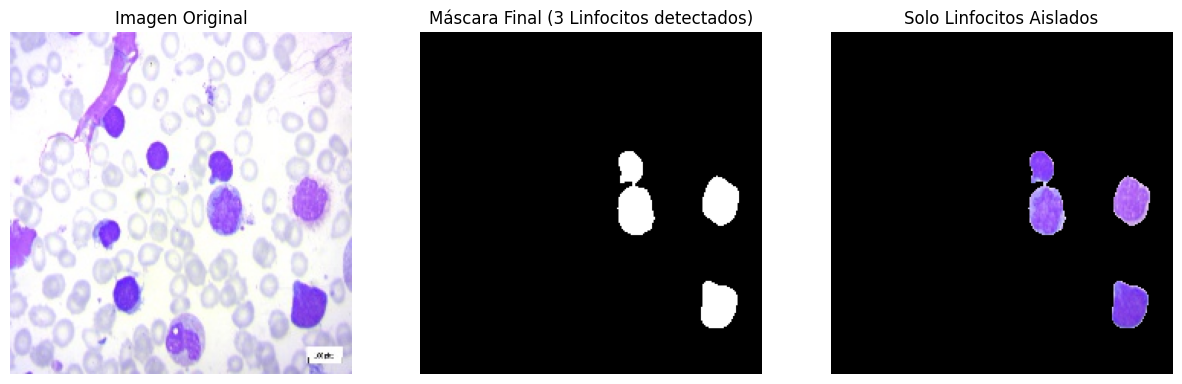

   Area_Celula  Area_Nucleo  Solidez_Celula  Circularidad_Nucleo
0        555.5        519.5        0.963573             0.802673
1        546.5        463.0        0.971556             0.816271
2        832.0        495.0        0.832000             0.826191


In [ ]:
# Suponiendo que 'mask_raw' es la máscara que salió de Otsu 
# 'img_rgb' es tu imagen original a color
# y 'mascara_nucleos' es tu máscara de núcleos unicamente

mascara_nucleos = segmentar_nucleo_estricto(canal_proc)

mascara_filtrada, img_limpia, datos = clasificar_y_filtrar_linfocitos(mask_raw, mascara_nucleos, img_rgb)

mascara_filtrada

# Mostrar el resultado de la limpieza
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(img_rgb)
axs[0].set_title("Imagen Original")
axs[0].axis('off')

axs[1].imshow(mascara_filtrada, cmap='gray')
axs[1].set_title(f"Máscara Final ({len(datos)} Linfocitos detectados)")
axs[1].axis('off')

axs[2].imshow(img_limpia)
axs[2].set_title("Solo Linfocitos Aislados")
axs[2].axis('off')

plt.show()

# Ver los datos matemáticos extraídos
df_celulas = pd.DataFrame(datos)
print(df_celulas)

In [ ]:
"Comentarios:"
"- Falta agregar una forma para cuando hay celulas muy pegadas las diferencie. "
"porque al tomar las 2 juntas la funcion clasificar_y_filtrar_linfocitos no elimina las mas chicas que "
"esten pegadas a un linfocito "

"- Falta filtrar a algunos basofilos: en teoria clasificar_y_filtrar_linfocitos los filtra por la"
" solidez del nucleo pero hay algunos que no son eliminados correctamente, al intentar subir el"
" valor de solidez deberia eliminarlos pero tambien elimina algunos linfocitos"